## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# basic imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

### Details of input file (DESI DR1 Spectra)

In [2]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')
header = hdul[0].header
hdul.close()
print(header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  AUTHOR  = 'A.Anand '                                                            FIT     = 'NMF     '                                                            SMOOTH  = 'MEDFILT: PIXSIZE=71'                                                 TGTQSO  = 'DESI DR1'                                                            END                                                                                                                                                                                                                                                                                                                                                                     

- I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the results as `../data/desi/MgII_cat.fits` and `../data/desi/CIV_cat.fits`.

### Exploring output

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/desi/MgII_cat.fits
  ABSORBER: 34 rows
  METADATA: 34 rows
  COLUMN_DENSITY: 34 rows
INFO: Time taken to read catalog from ../data/desi/MgII_cat.fits 0.03 seconds


Text(0.5, 0, 'MgII redshift')

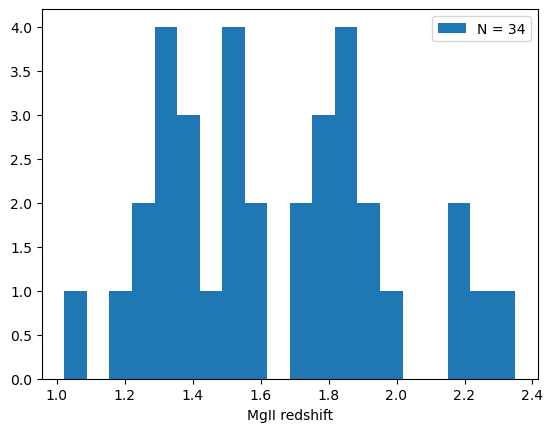

In [3]:
from qsoabsfind.datamodel import AbsorberData
mgii_tab = AbsorberData(f'../data/desi/MgII_cat.fits', autoload=True)
zabs = mgii_tab.catalog["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

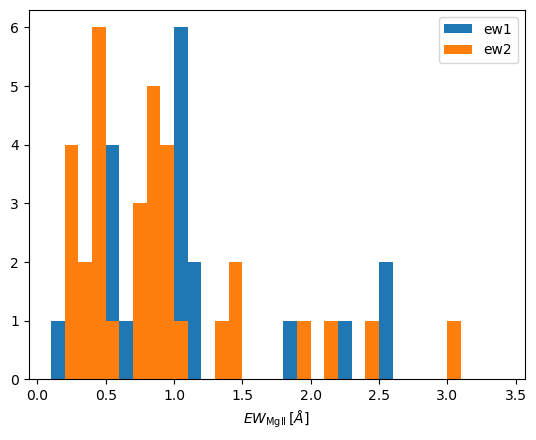

In [4]:
ew1 = mgii_tab.catalog["MGII_2796_EW"].data
ew2 = mgii_tab.catalog["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra

INFO: plotting QSO INDEX = 46...
INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.02 seconds


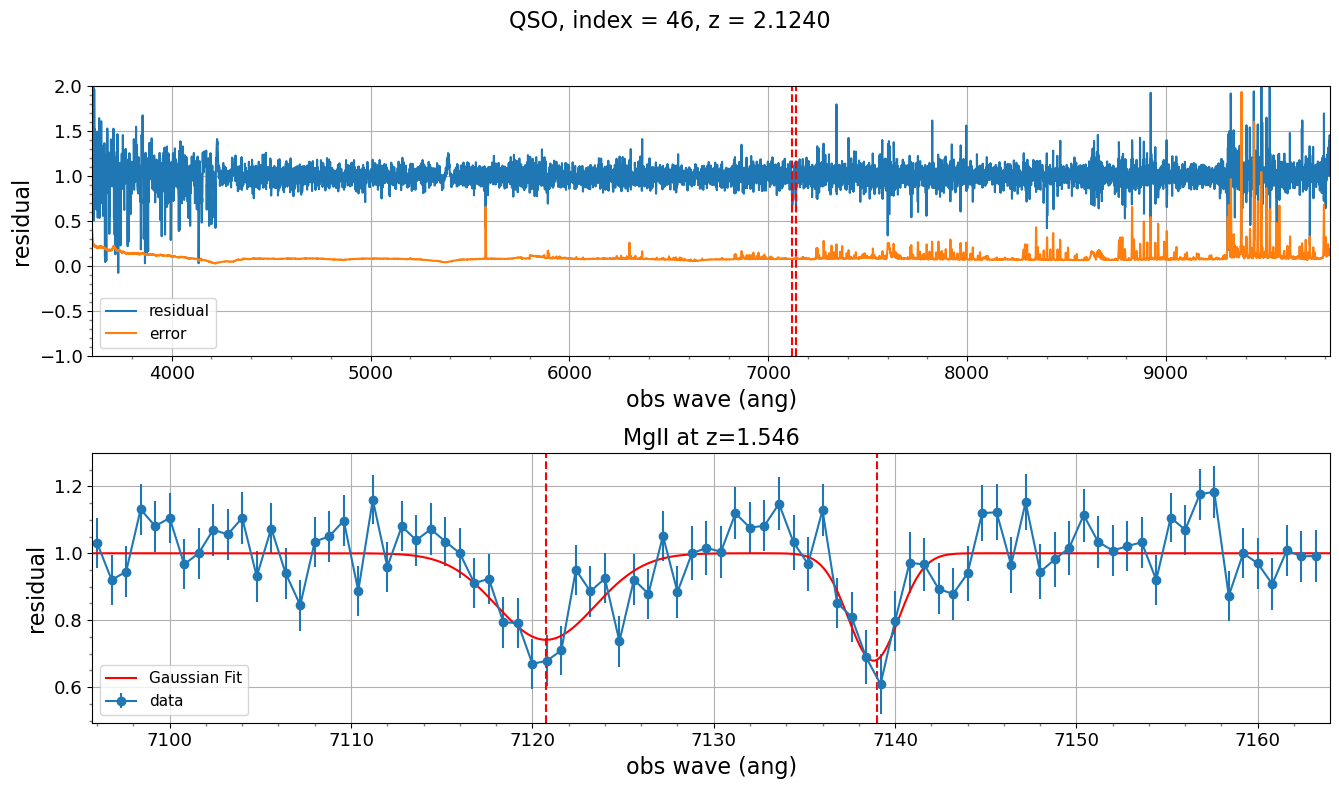

In [5]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab.catalog["INDEX_SPEC"].data)
print(f'INFO: plotting QSO INDEX = {index}...')
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab.catalog[mgii_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)

### Using qsoabsfind internally as module

In [6]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.config import load_constants
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., MgII, CIV, OVI, NV, SiIV, AlIII, FeII).
        kwargs (dict): search parameters as taken in convolution_method..()
    
    Returns:
      

In [7]:
parameters = load_constants(f'../data/desi/desi_constants.py')
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', index, 'MgII', **parameters.search_parameters)

/Users/abhijeet/opt/anaconda3/lib/python3.9/site-packages/scipy/optimize/_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


{'index_spec': [46],
 'z_abs': [1.5464356460330575],
 'gauss_fit': [[0.2585478628026734,
   2796.3602243502023,
   1.0660087265822584,
   0.3209755693552435,
   2803.454645395147,
   0.545016855517186]],
 'gauss_fit_std': [[0.037414401103720005,
   0.17843944369669634,
   0.17845180711549957,
   0.058791111988884814,
   0.1129989492489438,
   0.11117163882591209]],
 'ew_1_mean': [0.6908625364303589],
 'ew_2_mean': [0.4385022819042206],
 'ew_total_mean': [1.1293648481369019],
 'ew_1_error': [0.015677092596888542],
 'ew_2_error': [0.009127217344939709],
 'ew_total_error': [0.018140489235520363],
 'z_abs_err': [9.640411735745147e-05],
 'sn_1': [5.9593440785155],
 'sn_2': [5.091402917674174],
 'vel_disp1': [109.20896826123493],
 'vel_disp2': [47.62518316735154],
 'delta_chi2': [117.79435729980469]}

Reading extension 'PRIMARY' (PrimaryHDU)
Reading extension 'ABSORBER' (BinTableHDU)
Reading extension 'METADATA' (BinTableHDU)
Reading extension 'COLUMN_DENSITY' (BinTableHDU)
Loaded 4 extensions from ../data/desi/CIV_cat.fits
  ABSORBER: 8 rows
  METADATA: 8 rows
  COLUMN_DENSITY: 8 rows
INFO: Time taken to read catalog from ../data/desi/CIV_cat.fits 0.03 seconds


Text(0.5, 0, 'CIV redshift')

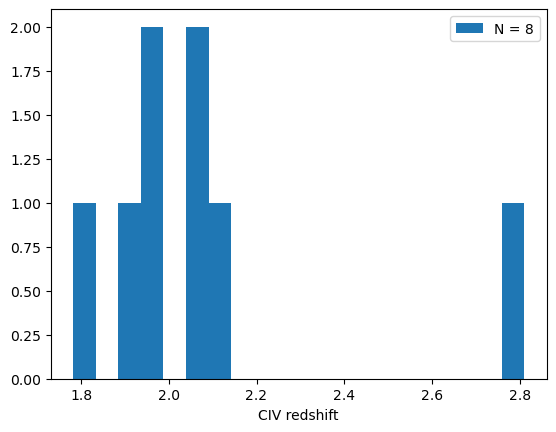

In [8]:
civ_tab = AbsorberData(f'../data/desi/CIV_cat.fits', autoload=True)
civ_zabs = civ_tab.catalog["Z_ABS"].data
plt.hist(civ_zabs, bins=20, label = f'N = {civ_zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')

INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.02 seconds
INFO: plotting CIV for QSO INDEX = 90...


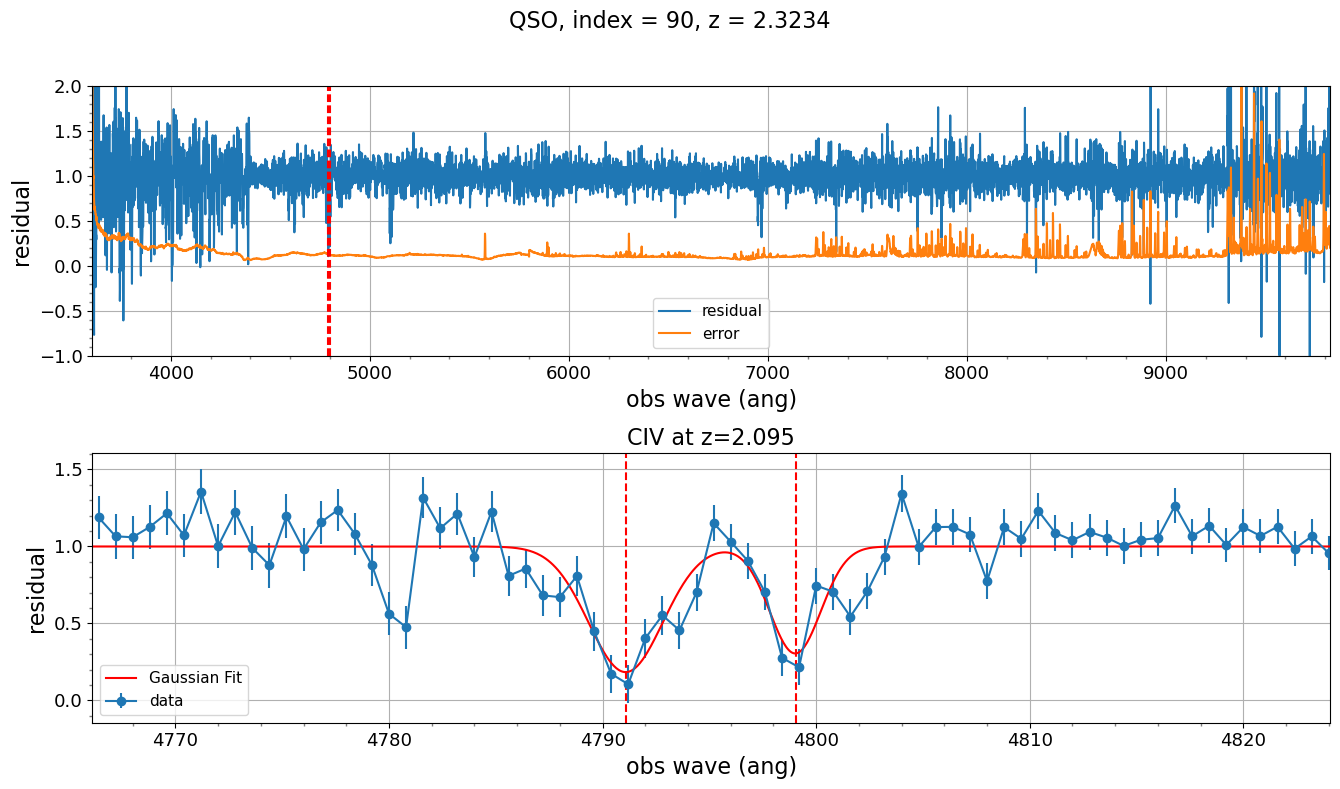

In [9]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.datamodel import QSOSpecRead

# select a random spectra from MgII_cat.fits
index = np.random.choice(civ_tab.catalog["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)
print(f'INFO: plotting CIV for QSO INDEX = {index}...')
# select corresponding zabs table
zabs = civ_tab.catalog[civ_tab.catalog["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z_QSO"]:.4f}', plot_filename=None)